# Plot example case of echo top and base heights and 2D histogram for that case and for whole campaign

- SEA-POL volume level 4v1.2

In [1]:
import xarray as xr
import numpy as np
import pandas as pd

from scipy.interpolate import interp2d, RectBivariateSpline
from datetime import datetime, timedelta
import cftime
import json
import glob
import os

import matplotlib.pyplot as plt
from matplotlib import rc, colors, ticker
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap
import matplotlib.ticker as mticker

import cartopy
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import seaborn as sns

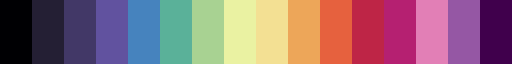

In [2]:
# Load colormap

# Read the colormap from a .txt file
def load_colormap_from_txt(file_path):
    # Load RGB values from the file
    rgb_values = np.loadtxt(file_path)
    return ListedColormap(rgb_values)

# Example usage
colormap_file = 'chase-spectral-rgb.txt'  # Replace with your .txt file path
radar_cmap = load_colormap_from_txt(colormap_file)

discrete_cmap = ListedColormap(radar_cmap(np.linspace(0, 1, 16)))
discrete_mask_cmap = discrete_cmap.copy()
discrete_mask_cmap.set_under(color='white') #set values below vmin to white
discrete_mask_cmap.set_bad(color='lightgray') #set missing (NaN) values to gray

discrete_mask_cmap

SEA-POL data

In [3]:
# read in data
#seapol = xr.open_dataset('/huracan/tank4/cornell/ORCESTRA/sea-pol/qc_data/level4v1.2/PICCOLO_level4_volume_3D.nc')
seapol = xr.open_dataset("ipfs://bafybeifryiuhi64d6vjod6mkrfaa3rxtjrfjlv7lmvjznagzpb3q6bfyea", engine="zarr")
seapol

<xarray.Dataset> Size: 427GB
Dimensions:       (time: 8708, Z: 19, Y: 241, X: 241)
Coordinates:
  * X             (X) float32 964B -1.2e+05 -1.19e+05 ... 1.19e+05 1.2e+05
  * Y             (Y) float32 964B -1.2e+05 -1.19e+05 ... 1.19e+05 1.2e+05
  * Z             (Z) float32 76B 0.0 1e+03 2e+03 ... 1.6e+04 1.7e+04 1.8e+04
    latitude      (time, Y, X) float32 2GB ...
    longitude     (time, Y, X) float32 2GB ...
  * time          (time) datetime64[ns] 70kB 2024-08-16T08:10:00 ... 2024-09-...
Data variables: (12/15)
    DBZ           (time, Z, Y, X) float32 38GB ...
    HID_CSU       (time, Z, Y, X) float32 38GB ...
    KDP           (time, Z, Y, X) float32 38GB ...
    MASK          (time, Z, Y, X) float32 38GB ...
    PHIDP         (time, Z, Y, X) float32 38GB ...
    RAINRATE      (time, Z, Y, X) float32 38GB ...
    ...            ...
    WIDTH         (time, Z, Y, X) float32 38GB ...
    ZDR           (time, Z, Y, X) float32 38GB ...
    grid_mapping  int32 4B ...
    heading       (time) float32 35kB ...
    start_time    (time) datetime64[ns] 70kB ...
    stop_time     (time) datetime64[ns] 70kB ...
Attributes: (12/15)
    Conventions:       CF-1.12
    institution:       Colorado State University
    creator_email:     mmbell@colostate.edu
    creator_id:        https://orcid.org/0000-0002-0496-331X
    project:           PICCOLO, BOWTIE, ORCESTRA
    platform:          RV METEOR
    ...                ...
    version:           v1.2
    creator_name:      Michael M. Bell, Brenda Dolan, Jennifer DeHart, Delián...
    title:             Level 4 Gridded Sea-Pol Radar Data Volume 3D
    summary:           This dataset contains the processed Level 3 Sea-Pol ra...
    source:            Colorado State University Sea-Pol radar
    instrument:        Colorado State University Sea-Pol radar

In [ ]:
# sea-pol echo base & top height data [already calculated over entire campaign by calc_echobasetopheight.py]
seapol_echobasetop = xr.open_dataset('../../data/SEA-POLv1.2_echo_base_top_height_vol1_10dbz_confident.nc')

Calculate percentages of echo base height

In [6]:
#Calculate percentage of echo base heights greater than 0 km
n_echo_0km = np.size(np.where(seapol_echobasetop.echo_base_height.values>0))/(np.size(seapol_echobasetop.echo_base_height.values))
print('Fraction of echo bases > 0 km:', n_echo_0km)

#Calculate percentage of echo base heights greater than 1 km
n_echo_1km = np.size(np.where(seapol_echobasetop.echo_base_height.values>1000))/(np.size(seapol_echobasetop.echo_base_height.values))
print('Fraction of echo bases > 1 km:', n_echo_1km)

#Calculate percentage of echo base heights greater than 2 km
n_echo_2km = np.size(np.where(seapol_echobasetop.echo_base_height.values>2000))/(np.size(seapol_echobasetop.echo_base_height.values))
print('Fraction of echo bases > 2 km:', n_echo_2km)

#Calculate percentage of echo base heights greater than 4 km 
n_echo_4km = np.size(np.where(seapol_echobasetop.echo_base_height.values>4000))/(np.size(seapol_echobasetop.echo_base_height.values))
print('Fraction of echo bases > 4 km:', n_echo_4km)

#Calculate percentage of echo base heights greater than 6 km 
n_echo_6km = np.size(np.where(seapol_echobasetop.echo_base_height.values>6000))/(np.size(seapol_echobasetop.echo_base_height.values))
print('Fraction of echo bases > 6 km:', n_echo_6km)

#Calculate percentage of echo base heights greater than 8 km 
n_echo_8km = np.size(np.where(seapol_echobasetop.echo_base_height.values>8000))/(np.size(seapol_echobasetop.echo_base_height.values))
print('Fraction of echo bases > 8 km:', n_echo_8km)

#Calculate percentage of echo base heights greater than 10 km 
n_echo_10km = np.size(np.where(seapol_echobasetop.echo_base_height.values>10000))/(np.size(seapol_echobasetop.echo_base_height.values))
print('Fraction of echo bases > 10 km:', n_echo_10km)

#Calculate percentage of echo base heights between 2-6 km
n_echo_congestus = np.size(np.where((seapol_echobasetop.echo_base_height.values>2000) & (seapol_echobasetop.echo_base_height.values<6000)))/(np.size(seapol_echobasetop.echo_base_height.values))
print('Fraction of echo bases > 2 km and < 6 km:', n_echo_congestus)

Fraction of echo bases > 0 km: 0.49310031386784525
Fraction of echo bases > 1 km: 0.21847380595057214
Fraction of echo bases > 2 km: 0.13322825796021856
Fraction of echo bases > 4 km: 0.053350609159294925
Fraction of echo bases > 6 km: 0.01869320716476264
Fraction of echo bases > 8 km: 0.004647374735835665


Fraction of echo bases > 10 km: 0.0008534755171095927
Fraction of echo bases > 2 km and < 6 km: 0.10099151345024256


Calculate SEA-POL echo base height for one single time to plot as a map

In [7]:
#Define time period for spatial map
time_map = np.datetime64('2024-09-02T10:40') # this is the time with the maximum elevated echofraction > 4 km out of total grid points

index_map = np.abs(pd.to_datetime(seapol.time) - time_map).argmin()
map_dbz = seapol.DBZ[index_map,:,:,:]

# set to nan outside of radius 120 km to only include data with the 3D volume
radius = 120  # km
distances = np.sqrt((map_dbz.latitude - map_dbz.latitude[120, 120])**2 + (map_dbz.longitude - map_dbz.longitude[120, 120])**2) * 111.32  # Approximate conversion from degrees to km
map_dbz = map_dbz.where(distances<=radius,np.nan)  # Set values outside the radius to NaN

In [11]:
#find the minimum height where the reflectivity is above a threshold
threshold = 10

# mask for valid (non-NaN) data
valid_data = ~np.isnan(map_dbz.values)

# mask for reflectivity above threshold
above_thresh = valid_data & (map_dbz.values >= threshold)

# Find the lowest index (height) where above_thresh is True for each (y, x), if not found return -1
min_indices = np.where(above_thresh.any(axis=0), np.argmax(above_thresh, axis=0), -1)

# Find the highest index (height) where above_thresh is True for each (y, x), if not found return -1
max_indices = np.where(above_thresh.any(axis=0), above_thresh.shape[0] - 1 - np.argmax(above_thresh[::-1], axis=0), -1)

# Initialize output: NaN where no valid data, -5 where there is at least some valid data
echo_base_height = np.full(map_dbz.shape[1:], np.nan)
echo_top_height = np.full(map_dbz.shape[1:], np.nan)
has_valid = valid_data.any(axis=0)
echo_base_height[has_valid] = -5
echo_top_height[has_valid] = -5

# Set echo top height where threshold is met
valid_top = max_indices != -1 #this is a mask for where the threshold is met

#also check that the maximum index is not at the top of the profile (nan above)
above_max_indices = np.copy(max_indices)
above_max_indices[valid_top] = above_max_indices[valid_top] + 1 # this is the index just above the maximum index where the threshold is met
dBZabove = np.full(map_dbz.shape[1:], np.nan)

#grab dbz value at the index above the maximum index where the threshold is met (if valid)
#for i in range(map_dbz.shape[1]):
#    for j in range(map_dbz.shape[2]):
#        dBZabove[i,j] = map_dbz.values[above_max_indices[i,j].astype(int), i, j]
# vectorized: only grab values where there is a potential valid top (where threshold is met)
valid_above = valid_top & (above_max_indices >= 0) & (above_max_indices < map_dbz.shape[0])
yy, xx = np.where(valid_above)
zz = above_max_indices[yy, xx].astype(int)
dBZabove[yy, xx] = map_dbz.values[zz, yy, xx]

#if the dbz value above the max index is not valid (nan), set the max index and min index to -1
#basically also limiting echo base height to where there is a confident echo top height
confident_max_indices = np.copy(max_indices)
confident_max_indices = np.where(~np.isnan(dBZabove), confident_max_indices, -1)
confident_min_indices = np.copy(min_indices)
confident_min_indices = np.where(~np.isnan(dBZabove), confident_min_indices, -1)
confident_valid_top = confident_max_indices != -1 #this is a mask for where the threshold is met and there is valid data above the max index
confident_valid_base = confident_min_indices != -1 

#print fraction of valid tops that are confident
print('Fraction of valid tops that are confident:', np.sum(confident_valid_top) / np.sum(valid_top) if np.sum(valid_top) > 0 else np.nan)
print('Number of confident valid tops:', np.sum(confident_valid_top))
print('Number of valid bases:', np.sum(confident_valid_base))

#grab the values of the height at the indices of the confident valid tops
echo_top_height[confident_valid_top] = map_dbz.Z.values[confident_max_indices[confident_valid_top].astype(int)]
echo_base_height[confident_valid_base] = map_dbz.Z.values[confident_min_indices[confident_valid_base].astype(int)]

Fraction of valid tops that are confident: 0.886401524172422
Number of confident valid tops: 7444
Number of valid bases: 7444


In [12]:
print('case study stats')
# Calculate fraction of echoes in this scene that are elevated
elevated_fraction = len(np.where(echo_base_height[confident_valid_base].flatten()>1000)[0]) / len(echo_base_height[confident_valid_base].flatten()) if len(echo_base_height[confident_valid_base].flatten()) > 0 else np.nan
print('Elevated echo fraction (>1 km):', elevated_fraction)

elevated_fraction = len(np.where(echo_base_height[confident_valid_base].flatten()>2000)[0]) / len(echo_base_height[confident_valid_base].flatten()) if len(echo_base_height[confident_valid_base].flatten()) > 0 else np.nan
print('Elevated echo fraction (>2 km):', elevated_fraction)

elevated_fraction = len(np.where(echo_base_height[confident_valid_base].flatten()>3000)[0]) / len(echo_base_height[confident_valid_base].flatten()) if len(echo_base_height[confident_valid_base].flatten()) > 0 else np.nan
print('Elevated echo fraction (>3 km):', elevated_fraction)

elevated_fraction = len(np.where(echo_base_height[confident_valid_base].flatten()>4000)[0]) / len(echo_base_height[confident_valid_base].flatten()) if len(echo_base_height[confident_valid_base].flatten()) > 0 else np.nan
print('Elevated echo fraction (>4 km):', elevated_fraction)

case study stats
Elevated echo fraction (>1 km): 0.45566899516389037
Elevated echo fraction (>2 km): 0.4206072004298764
Elevated echo fraction (>3 km): 0.4069048898441698
Elevated echo fraction (>4 km): 0.39884470714669534


In [10]:
print('Mean Elevated Echo Fraction > 1 km:', np.nanmean(seapol_echobasetop.elevated_echo_fraction1.values))
print('Mean Elevated Echo Fraction > 2 km:', np.nanmean(seapol_echobasetop.elevated_echo_fraction2.values))
print('Mean Elevated Echo Fraction > 3 km:', np.nanmean(seapol_echobasetop.elevated_echo_fraction3.values))
print('Mean Elevated Echo Fraction > 4 km:', np.nanmean(seapol_echobasetop.elevated_echo_fraction4.values))

Mean Elevated Echo Fraction > 1 km: 0.2581788456562075
Mean Elevated Echo Fraction > 2 km: 0.15390804547843417
Mean Elevated Echo Fraction > 3 km: 0.09847957865266492
Mean Elevated Echo Fraction > 4 km: 0.06456732786488381


In [9]:
print('Fraction of times with elevated echo fraction [> 1 km] > 0:', np.sum(seapol_echobasetop.elevated_echo_fraction1.values>0)/len(seapol_echobasetop.elevated_echo_fraction1.values))
print('Fraction of times with elevated echo fraction [> 2 km] > 0:', np.sum(seapol_echobasetop.elevated_echo_fraction2.values>0)/len(seapol_echobasetop.elevated_echo_fraction2.values))
print('Fraction of times with elevated echo fraction [> 3 km] > 0:', np.sum(seapol_echobasetop.elevated_echo_fraction3.values>0)/len(seapol_echobasetop.elevated_echo_fraction3.values))
print('Fraction of times with elevated echo fraction [> 4 km] > 0:', np.sum(seapol_echobasetop.elevated_echo_fraction4.values>0)/len(seapol_echobasetop.elevated_echo_fraction4.values))

Fraction of times with elevated echo fraction [> 1 km] > 0: 0.8541440463264568
Fraction of times with elevated echo fraction [> 2 km] > 0: 0.8145132102786826
Fraction of times with elevated echo fraction [> 3 km] > 0: 0.761672095548317
Fraction of times with elevated echo fraction [> 4 km] > 0: 0.6965255157437568


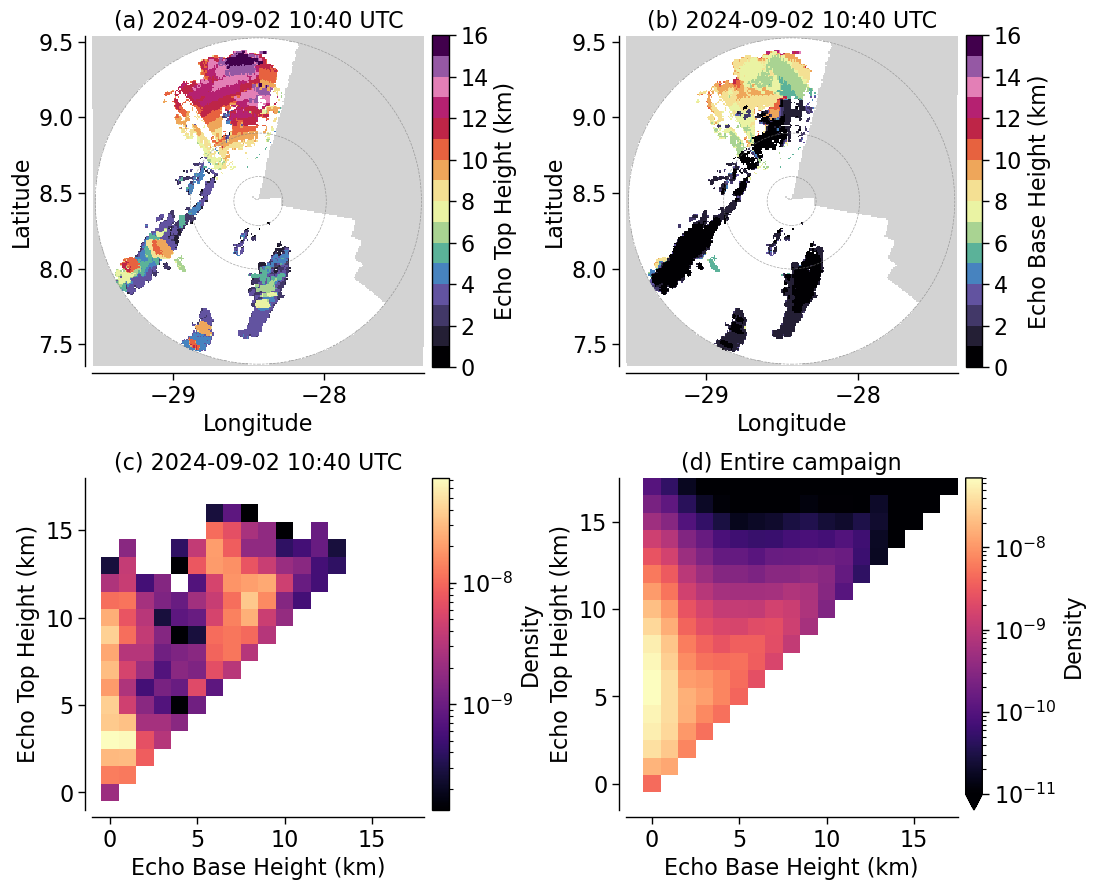

In [15]:
#Plot specific scene
fig, axs = plt.subplots(2,2,figsize=(11,9))

seapol_bins = np.concatenate(([-1],np.arange(0, 18500, 1000)))

###############SCENE-SPECIFIC 2D HISTOGRAM OF ECHO BASE HEIGHT VS ECHO TOP HEIGHT ##############
ebh_eth_2dhist, ebh_edges, eth_edges = np.histogram2d(echo_base_height[confident_valid_base].flatten(), echo_top_height[confident_valid_top].flatten(), bins=[seapol_bins, seapol_bins], density=True)
bin_areas = np.diff(ebh_edges)[:, None] * np.diff(eth_edges)[None, :]
ebh_eth_prob = ebh_eth_2dhist * bin_areas  # Convert density to probability

#create a copy of the colorbar and set Nan values to white
magma_white = plt.cm.magma.copy()
magma_white.set_bad(color='white')

# set zero values to NaN
ebh_eth_2dhist[ebh_eth_2dhist==0] = np.nan

X, Y = np.meshgrid(np.concatenate(([-1], ebh_edges[1:-1]/1000)), np.concatenate(([-1], eth_edges[1:-1]/1000)))
cax = axs[1,0].pcolormesh(X, Y, ebh_eth_2dhist.T, shading='nearest', cmap=magma_white, norm=colors.LogNorm(vmin=np.nanmin(ebh_eth_2dhist), vmax=np.nanmax(ebh_eth_2dhist)))
cbar = fig.colorbar(cax, ax=axs[1,0], orientation='vertical',pad=0.02)
cbar.ax.tick_params(labelsize=16)
cbar.ax.set_ylabel('Density', fontsize=16)
axs[1,0].set_xlim([-1,18])
axs[1,0].set_ylim([-1,18])
axs[1,0].set_xlabel('Echo Base Height (km)', fontsize=16)
axs[1,0].set_ylabel('Echo Top Height (km)', fontsize=16)
dt_str = pd.to_datetime(seapol.time[index_map].values).strftime('%Y-%m-%d %H:%M')
axs[1,0].set_title('(c) ' + dt_str + ' UTC',fontsize=16)
axs[1,0].tick_params(axis='both', labelsize=16)
axs[1,0].set_aspect('equal', adjustable='box')

####################### CAMPAIGN-WIDE 2D HISTOGRAM OF ECHO BASE HEIGHT VS ECHO TOP HEIGHT #######################
ebh_eth_2dhist, ebh_edges, eth_edges = np.histogram2d(seapol_echobasetop.echo_base_height.values.flatten(), seapol_echobasetop.echo_top_height.values.flatten(), bins=[seapol_bins, seapol_bins], density=True)
bin_areas = np.diff(ebh_edges)[:, None] * np.diff(eth_edges)[None, :]
ebh_eth_prob = ebh_eth_2dhist * bin_areas  # Convert density to probability

#create a copy of the colorbar and set Nan values to white
magma_white = plt.cm.magma.copy()
magma_white.set_bad(color='white')

# set zero values to NaN
ebh_eth_2dhist[ebh_eth_2dhist==0] = np.nan

X, Y = np.meshgrid(np.concatenate(([-1], ebh_edges[1:-1]/1000)), np.concatenate(([-1], eth_edges[1:-1]/1000)))
cax = axs[1,1].pcolormesh(X, Y, ebh_eth_2dhist.T, shading='nearest', cmap=magma_white, norm=colors.LogNorm(vmin=1e-11, vmax=7e-8))
cbar0 = fig.colorbar(cax, ax=axs[1,1], orientation='vertical',pad=0.02,extend='min')
cbar0.ax.tick_params(labelsize=16)
cbar0.ax.set_ylabel('Density', fontsize=16)
axs[1,1].set_xlabel('Echo Base Height (km)', fontsize=16)
axs[1,1].set_ylabel('Echo Top Height (km)', fontsize=16)
axs[1,1].set_title('(d) Entire campaign',fontsize=16)
axs[1,1].tick_params(axis='both', labelsize=16)
axs[1,1].set_aspect('equal', adjustable='box')

#############SPATIAL MAP OF ECHO TOP HEIGHT ##############
cax = axs[0,0].pcolormesh(map_dbz.longitude, map_dbz.latitude, echo_top_height/1000, cmap=discrete_mask_cmap, vmin=0, vmax=16)
axs[0,0].set_aspect('equal',adjustable='box')
cbar1 = fig.colorbar(cax, ax=axs[0,0], orientation='vertical',pad=0.02)
cbar1.ax.tick_params(labelsize=16)
cbar1.set_ticks(np.arange(0,17,2))
cbar1.set_ticklabels(np.arange(0,17,2))
cbar1.ax.set_ylabel('Echo Top Height (km)', fontsize=16)
axs[0,0].set_title('(a) ' + dt_str + ' UTC',fontsize=16)
axs[0,0].tick_params(axis='both', labelsize=16)
axs[0,0].set_xlabel('Longitude', fontsize=16)
axs[0,0].set_ylabel('Latitude', fontsize=16)

# Add grid lines 
#axs[1,0].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
# Add 120 km circle
axs[0,0].add_patch(plt.Circle((map_dbz.longitude[120,120], map_dbz.latitude[120,120]), 120/111.32, color='gray', alpha = 0.7,fill=False, linestyle='--', linewidth=0.5))
# Add 50 km circle
axs[0,0].add_patch(plt.Circle((map_dbz.longitude[120,120], map_dbz.latitude[120,120]), 50/111.32, color='gray', alpha = 0.7,fill=False, linestyle='--', linewidth=0.5))
# Add 18 km circle
axs[0,0].add_patch(plt.Circle((map_dbz.longitude[120,120], map_dbz.latitude[120,120]), 18/111.32, color='gray', alpha = 0.7,fill=False, linestyle='--', linewidth=0.5))

##############SPATIAL MAP OF ECHO BASE HEIGHT ##############
cax = axs[0,1].pcolormesh(map_dbz.longitude, map_dbz.latitude, echo_base_height/1000, cmap=discrete_mask_cmap, vmin=0, vmax=16)
axs[0,1].set_aspect('equal',adjustable='box')
cbar2= fig.colorbar(cax, ax=axs[0,1], orientation='vertical',pad=0.02)
cbar2.ax.tick_params(labelsize=16)
cbar2.set_ticks(np.arange(0,17,2))
cbar2.set_ticklabels(np.arange(0,17,2))
cbar2.ax.set_ylabel('Echo Base Height (km)', fontsize=16)
axs[0,1].set_title('(b) ' + dt_str + ' UTC',fontsize=16)
axs[0,1].tick_params(axis='both', labelsize=16)
axs[0,1].set_xlabel('Longitude', fontsize=16)
axs[0,1].set_ylabel('Latitude', fontsize=16)

# Add grid lines 
#axs[1,1].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
# Add 120 km circle
axs[0,1].add_patch(plt.Circle((map_dbz.longitude[120,120], map_dbz.latitude[120,120]), 120/111.32, color='gray', alpha = 0.7,fill=False, linestyle='--', linewidth=0.5))
# Add 50 km circle
axs[0,1].add_patch(plt.Circle((map_dbz.longitude[120,120], map_dbz.latitude[120,120]), 50/111.32, color='gray', alpha = 0.7,fill=False, linestyle='--', linewidth=0.5))
# Add 18 km circle
axs[0,1].add_patch(plt.Circle((map_dbz.longitude[120,120], map_dbz.latitude[120,120]), 18/111.32, color='gray', alpha = 0.7,fill=False, linestyle='--', linewidth=0.5))

sns.set_context('paper') 
sns.despine(offset=5)
sns.despine(ax=cbar.ax, left=True, bottom=True, right=True, top=True)
sns.despine(ax=cbar0.ax, left=True, bottom=True, right=True, top=True)
sns.despine(ax=cbar1.ax, left=True, bottom=True, right=True, top=True)
sns.despine(ax=cbar2.ax, left=True, bottom=True, right=True, top=True)
plt.tight_layout() 

plt.savefig('./figures/Fig_echo_base_top.pdf', bbox_inches='tight', dpi=300)